<a href="https://colab.research.google.com/github/GabrieleSocrate/Text-Mining-/blob/main/LSTM_static_plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BiLSTM for sentimental analysis



## Research Goal
The goal of this work is to develop a sentiment analysis model capable of classifying the sentiment of financial news texts. In particular, we build a model based on a Bidirectional Long Short-Term Memory (BiLSTM) neural network to analyze the sentiment expressed in financial news articles. The model is trained on a financial news dataset and aims to identify the polarity of the text (e.g., positive, negative, or neutral).

After building and evaluating the BiLSTM model, its performance will be compared with a BERT-based model, which represents a more recent transformer-based approach for natural language processing tasks. This comparison allows us to analyze the differences in performance between a recurrent neural network architecture and a transformer-based architecture in the context of financial sentiment analysis.

## Import and Seed

In this section we import the libraries that will be used later in the code for data processing, model creation, training and evaluation.

In [ ]:
import os
import json
import random
import itertools
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    SpatialDropout1D,
    Bidirectional,
    Dropout,
    LeakyReLU
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    BackupAndRestore,
    CSVLogger
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from transformers import DistilBertTokenizer as _TempTokenizer



In [ ]:
SEED = 100
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

This code sets a fixed random seed to ensure reproducibility. The variable `SEED = 100` defines the seed value used to initialize random number generators. `random.seed(SEED)` sets the seed for Python’s `random` module, `np.random.seed(SEED)` sets the seed for NumPy and `tf.random.set_seed(SEED)` sets the seed for TensorFlow operations. This ensures that the experiment produces the same results every time the code is executed.


## Dataset Loading

In this section we mount Google Drive and load a **financial news dataset** stored in a JSONL file. The dataset contains financial news articles that will be used for the analysis and for training the model.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = "/content/drive/MyDrive/Ds/financial_news_base.jsonl"

df = pd.read_json(file_path, lines=True)

df.head()

,date_publish,description,maintext,title,mentioned_companies,related_companies,industries,sentiment,emotion,sentiment_label
0,2018-06-22 18:39:00,Morgan Stanley is telling its clients to pay a...,Morgan Stanley is telling its clients to pay a...,Morgan Stanley sees 'a pattern forming' of the...,[GOOGL],"[IGLD, RAMP, NSR, TWTR, ACXM, COR, PINS, META,...",[7375],"{'negative': 0.0005622319, 'neutral': 0.006970...","{'neutral': 0.9212942719, 'surprise': 0.039100...",positive
1,2018-11-15 00:00:00,"The FCC voted to grant ""market access"" request...",By David Shepardson\nWASHINGTON (Reuters - The...,"SpaceX, TeleSat Canada bids get U.S. nod to ex...","[TSLA, MU]","[IKGH, CLLS, EBIO, GMAB, GBS, WIMI, WALD, FGEN...","[3674, 9999]","{'negative': 0.0002858295, 'neutral': 0.001688...","{'neutral': 0.8668617606000001, 'joy': 0.05769...",positive
2,2018-12-29 19:57:55,(Bloomberg) -- A lawsuit filed against Google ...,(Bloomberg) -- A lawsuit filed against Google ...,Google Wins Dismissal of Suit Over Facial Reco...,[GOOGL],"[IGLD, RAMP, NSR, TWTR, ACXM, COR, PINS, META,...",[7375],"{'negative': 0.2307210714, 'neutral': 0.361657...","{'anger': 0.7141016126, 'neutral': 0.202039063...",positive
3,2018-09-12 18:42:40,"With camera upgrades, better screens and more",Apple on Wednesday unveiled a trio of new iPho...,"Apple Unveils iPhone XS, iPhone XS Max and Che...",[AAPL],"[None, TDC, HPQ, SCKT, OMCL, CRAY, ZEPP, IBM, ...",[3571],"{'negative': 0.0053426563, 'neutral': 0.164953...","{'neutral': 0.9592552185000001, 'surprise': 0....",positive
4,2018-04-23 20:03:16,Google is reporting on Monday.,"Google’s (GOOG, GOOGL) parent company Alphabet...",Alphabet Q1 2018 earnings,"[GOOGL, INTC, META, AAPL]","[IGLD, TDC, NSAT, CRAY, TCX, FLEX, SMCI, WBMD,...","[3571, 3679, 7375]","{'negative': 0.0003154654, 'neutral': 5.86179e...","{'neutral': 0.6759750247, 'surprise': 0.166648...",positive


## Exploratory Data Analysis

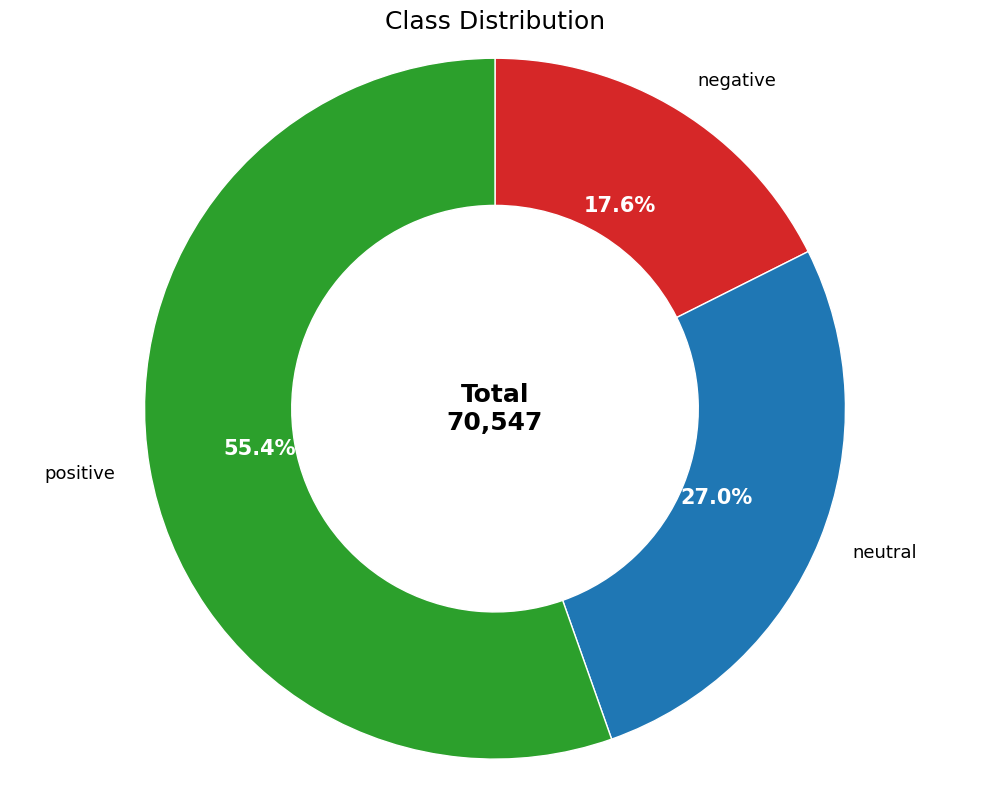

In [ ]:
labels = ['negative', 'neutral', 'positive']
sizes = [17.6, 27.0, 55.4]
colors = ['#d62728', '#1f77b4', '#2ca02c']
total = 70547

fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    startangle=90,
    counterclock=False,
    autopct='%1.1f%%',
    pctdistance=0.68,          # <-- percentuali più centrate
    labeldistance=1.10,
    wedgeprops=dict(width=0.42, edgecolor='white'),
    textprops=dict(color='black', fontsize=13)
)

for t in autotexts:
    t.set_color('white')
    t.set_fontsize(15)
    t.set_fontweight('bold')
    t.set_ha('center')
    t.set_va('center')

ax.text(
    0, 0,
    f'Total\n{total:,}',
    ha='center',
    va='center',
    fontsize=18,
    fontweight='bold'
)

ax.set_title('Class Distribution', fontsize=18)
ax.axis('equal')

plt.tight_layout()
plt.show()



The figure shows the distribution of sentiment labels in the financial news dataset. The dataset contains **70,547 news articles**, each classified into one of three sentiment categories: **positive, neutral, or negative**.

The majority of the articles are labeled as **positive**, accounting for **55.4% (39,098 articles)** of the dataset. **Neutral** articles represent **27% (19,028 articles)**, while **negative** articles constitute **17.6% (12,421 articles)**.

This distribution indicates that the dataset is **imbalanced**, with a significantly higher proportion of positive news compared to negative ones. Such imbalance is common in financial news datasets, where articles often report company growth, earnings, or positive market developments.

Understanding this distribution is important for the modeling phase, as class imbalance may influence the training of machine learning models.

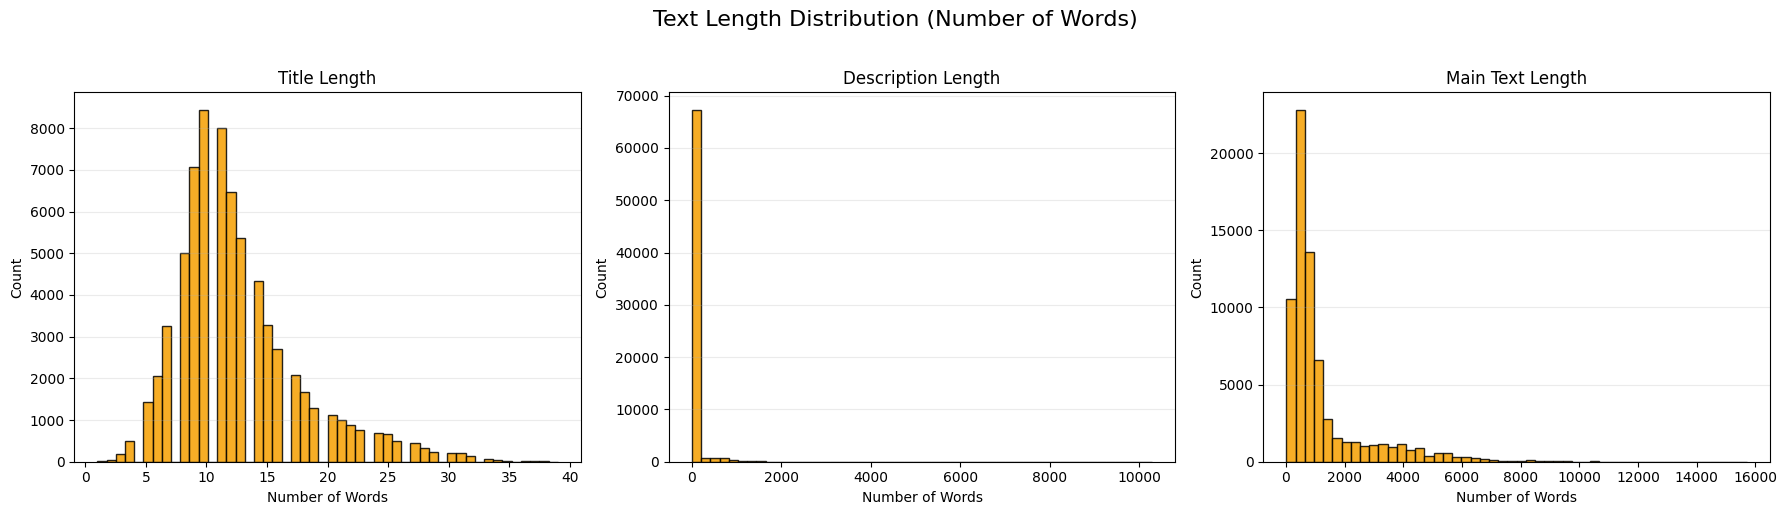

In [ ]:
df['title_len'] = df['title'].astype(str).apply(lambda x: len(x.split()))
df['description_len'] = df['description'].astype(str).apply(lambda x: len(x.split()))
df['maintext_len'] = df['maintext'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    (df['title_len'], 'Title Length'),
    (df['description_len'], 'Description Length'),
    (df['maintext_len'], 'Main Text Length')
]

for ax, (data, title) in zip(axes, datasets):
    ax.hist(data, bins=50, color='#F59F00', edgecolor='black', alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel('Number of Words')
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.25)

fig.suptitle('Text Length Distribution (Number of Words)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()



The figure illustrates the distribution of text length in the dataset by analyzing the number of words in three different components of each news article: **title**, **description**, and **main text**.

The **title length distribution** shows that most titles contain approximately **8 to 15 words**, with the highest concentration around **10–12 words**. This indicates that financial news headlines tend to be relatively short and concise.

The **description length distribution** is highly skewed toward shorter texts. Most descriptions contain a limited number of words, while a small number of samples include very long descriptions, which appear as outliers in the distribution.

The **main text length distribution** shows a much wider range of values. Although many articles contain relatively short main texts, some articles are significantly longer, reaching several thousand words. This results in a long-tailed distribution.

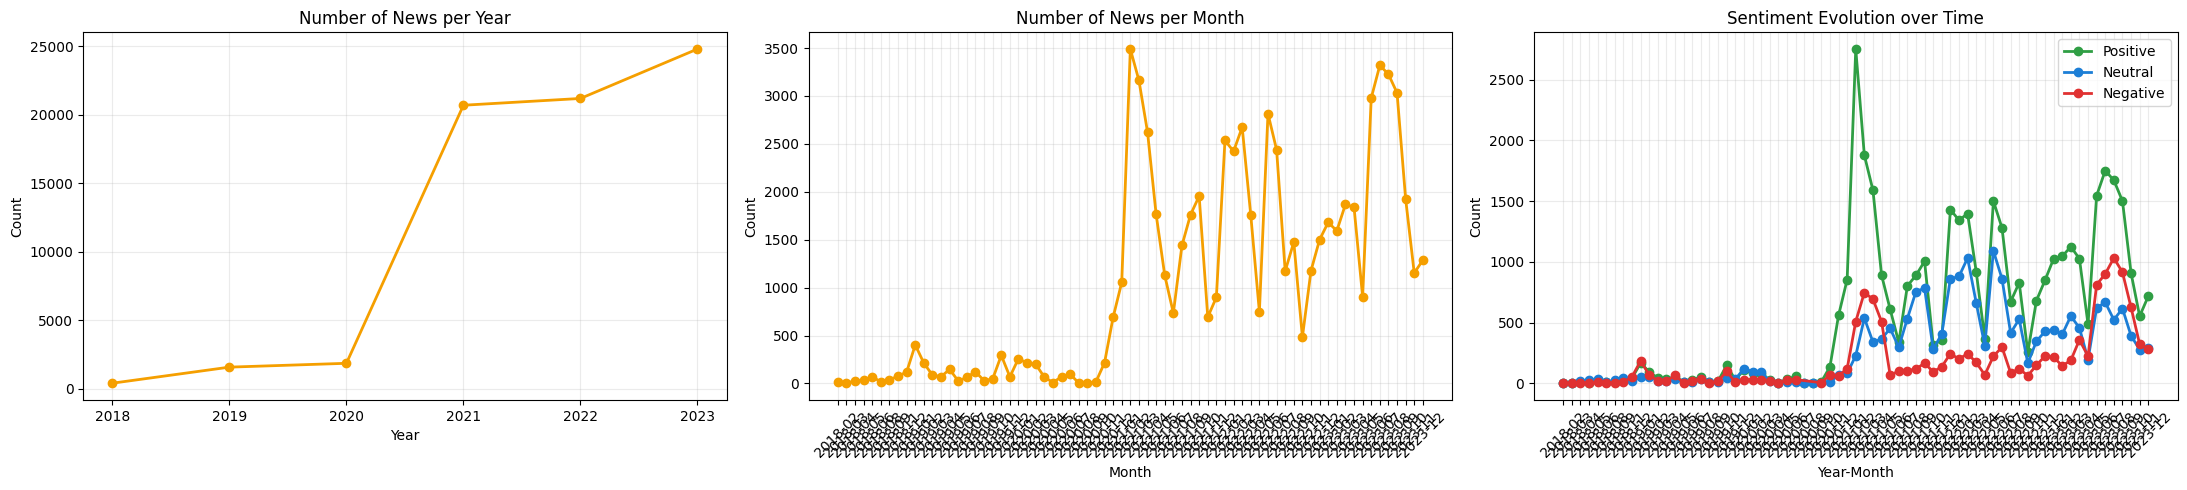

In [ ]:
df['date_publish'] = pd.to_datetime(df['date_publish'], errors='coerce')

df_time = df.dropna(subset=['date_publish']).copy()

news_per_year = (
    df_time
    .groupby(df_time['date_publish'].dt.year)
    .size()
    .reset_index(name='count')
)
news_per_year.columns = ['year', 'count']

news_per_month = (
    df_time
    .groupby(df_time['date_publish'].dt.to_period('M'))
    .size()
    .reset_index(name='count')
)
news_per_month['date_publish'] = news_per_month['date_publish'].astype(str)

sentiment_time = df_time.copy()
sentiment_time['year_month'] = sentiment_time['date_publish'].dt.to_period('M').astype(str)

sentiment_counts = (
    sentiment_time
    .groupby(['year_month', 'sentiment_label'])
    .size()
    .reset_index(name='count')
)

orange_color = '#F59F00'
colors = {
    'positive': '#2F9E44',
    'neutral': '#1C7ED6',
    'negative': '#E03131'
}

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

axes[0].plot(news_per_year['year'], news_per_year['count'], marker='o', linewidth=2, color=orange_color)
axes[0].set_title('Number of News per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].grid(alpha=0.25)

axes[1].plot(news_per_month['date_publish'], news_per_month['count'], marker='o', linewidth=2, color=orange_color)
axes[1].set_title('Number of News per Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.25)

for sentiment in ['positive', 'neutral', 'negative']:
    temp = sentiment_counts[sentiment_counts['sentiment_label'] == sentiment]
    axes[2].plot(
        temp['year_month'],
        temp['count'],
        marker='o',
        linewidth=2,
        label=sentiment.capitalize(),
        color=colors[sentiment]
    )

axes[2].set_title('Sentiment Evolution over Time')
axes[2].set_xlabel('Year-Month')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()



The figure presents the temporal distribution of financial news articles in the dataset, showing the number of articles published per **year**, per **month**, and the **evolution of sentiment over time**.

The first plot shows a clear increase in the number of news articles after **2020**. However, it is important to note that the relatively small number of articles before 2020 does not necessarily reflect a lower level of financial news production during that period. Instead, it is mainly due to the dataset containing **fewer articles from earlier years**, as fewer samples from that period were included during data collection.

Starting from **2021**, the number of articles increases significantly and continues to grow in the following years. This period coincides with a highly dynamic phase in global financial markets, influenced by major economic events such as the **COVID-19 pandemic**, the subsequent economic recovery, and increased market volatility. These events likely contributed to a higher volume of financial news coverage.

The monthly distribution further highlights fluctuations in news volume, with noticeable peaks during certain months. These variations may be related to major financial events, earnings seasons, macroeconomic announcements, or periods of heightened market uncertainty.

The third plot shows the **evolution of sentiment over time**. Positive sentiment generally remains the most frequent category throughout the observed period, while neutral and negative sentiments appear less frequently but still follow similar temporal patterns. Around **2021**, there is a visible increase in sentiment activity across all categories, which aligns with the rise in the total number of articles in the dataset.

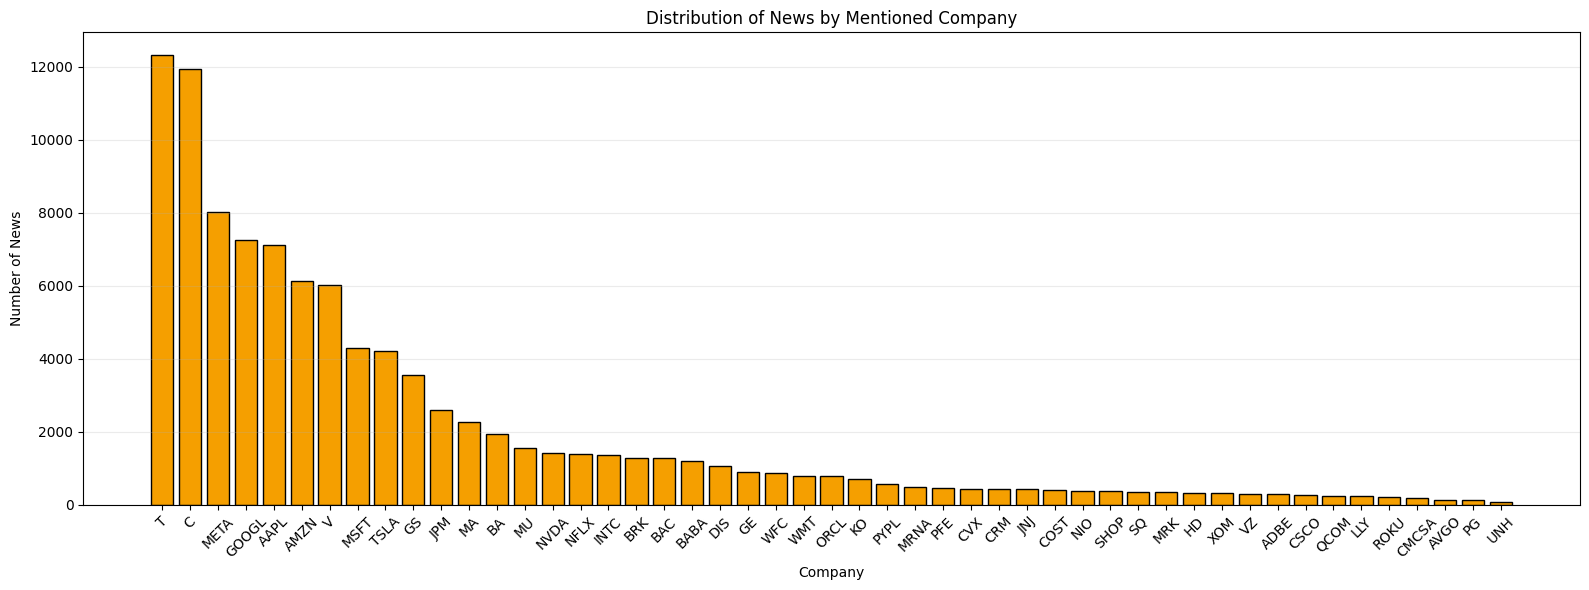

In [ ]:
df_companies = df[['mentioned_companies', 'sentiment_label']].copy()

df_companies = df_companies[df_companies['mentioned_companies'].notna()].copy()
df_companies = df_companies.explode('mentioned_companies')

df_companies = df_companies[df_companies['mentioned_companies'].notna()].copy()

total_counts = (
    df_companies.groupby('mentioned_companies')
    .size()
    .reset_index(name='total_news')
)

sentiment_counts = (
    df_companies.groupby(['mentioned_companies', 'sentiment_label'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for col in ['positive', 'neutral', 'negative']:
    if col not in sentiment_counts.columns:
        sentiment_counts[col] = 0

company_stats = total_counts.merge(sentiment_counts, on='mentioned_companies', how='left')
company_stats = company_stats.sort_values('total_news', ascending=False)

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(company_stats['mentioned_companies'], company_stats['total_news'], color='#F59F00', edgecolor='black')
ax.set_title('Distribution of News by Mentioned Company')
ax.set_xlabel('Company')
ax.set_ylabel('Number of News')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()



The figure shows the distribution of financial news articles according to the **companies mentioned in the dataset**. Each bar represents the number of articles in which a specific company appears.

The distribution is clearly **highly skewed**, with a small number of companies dominating the dataset. Companies such as **Tesla (TSLA)**, **Citigroup (C)**, **Meta (META)**, **Alphabet (GOOGL)**, and **Apple (AAPL)** appear most frequently in the articles. These companies are among the most influential and widely followed firms in global financial markets, which explains their strong presence in financial news coverage.

Other large technology companies, including **Amazon (AMZN)** and **Microsoft (MSFT)**, also appear frequently, reflecting the central role of the technology sector in financial reporting. In addition, several major financial institutions such as **Goldman Sachs (GS)**, **JPMorgan (JPM)**, and **Bank of America (BAC)** are prominently represented.

Beyond these dominant companies, the distribution gradually decreases, with many firms appearing only a limited number of times. This long-tail pattern suggests that while the dataset covers a wide range of companies, financial news tends to concentrate on a relatively small group of highly influential corporations.

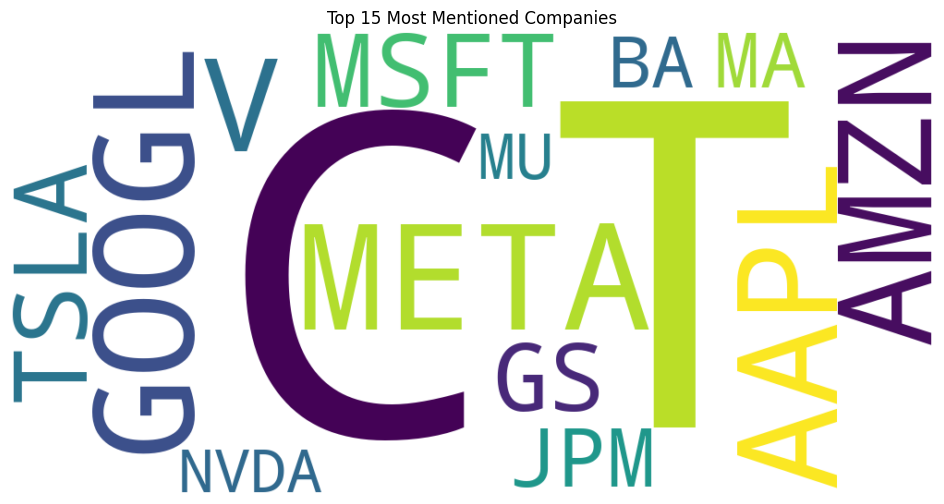

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

companies = df['mentioned_companies'].dropna().explode()

top_companies = companies.value_counts().head(15)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='viridis'
).generate_from_frequencies(top_companies)

# Plot
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Top 15 Most Mentioned Companies")
plt.show()

## Class Balancing

In [ ]:
MAX_LEN = 256

# Step 1: Filter rows with more than 256 tokens on the ORIGINAL dataset (before balancing)
_tokenizer_temp = _TempTokenizer.from_pretrained("distilbert-base-uncased")
mask_256 = df["description"].apply(
    lambda t: len(_tokenizer_temp.encode(str(t), add_special_tokens=True)) <= MAX_LEN
)
df_filtered = df[mask_256].reset_index(drop=True)

# Step 2: Balance classes AFTER filtering
target_per_class = 25000 // 3

dfs = []
for label in df_filtered["sentiment_label"].unique():
    subset = df_filtered[df_filtered["sentiment_label"] == label]
    dfs.append(subset.sample(n=target_per_class, random_state=100))

df_balanced = pd.concat(dfs).sample(frac=1, random_state=100).reset_index(drop=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1534 > 512). Running this sequence through the model will result in indexing errors


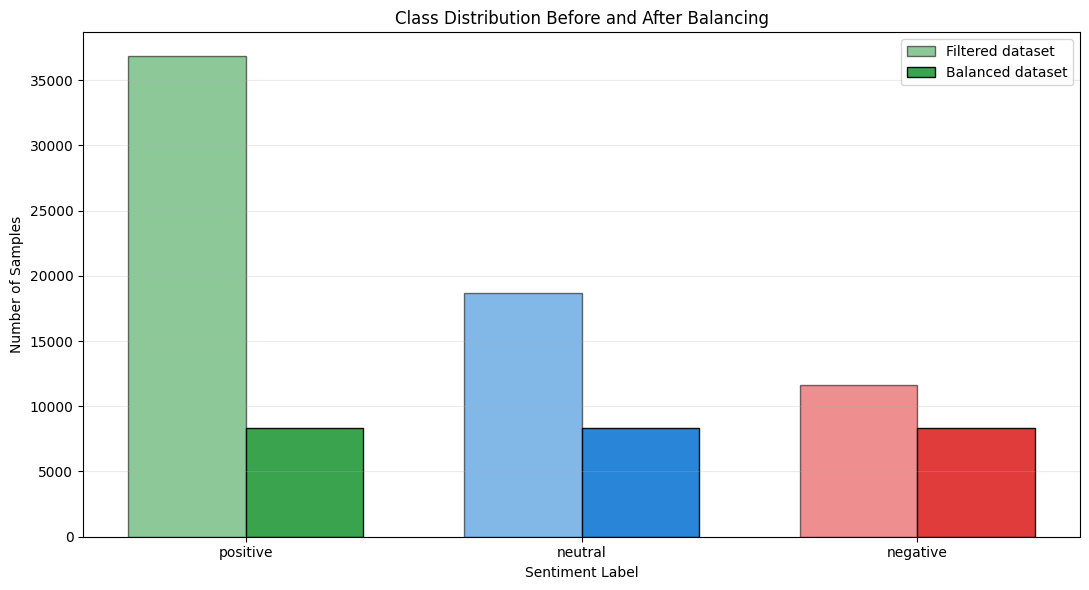

In [ ]:
order = ['positive', 'neutral', 'negative']

old_counts = (
    df_filtered['sentiment_label']
    .value_counts()
    .reindex(order, fill_value=0)
)

new_counts = (
    df_balanced['sentiment_label']
    .value_counts()
    .reindex(order, fill_value=0)
)

colors = {
    'positive': '#2F9E44',
    'neutral': '#1C7ED6',
    'negative': '#E03131'
}

x = np.arange(len(order))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(
    x - width/2,
    old_counts.values,
    width,
    label='Filtered dataset',
    color=[colors[label] for label in order],
    alpha=0.55,
    edgecolor='black'
)
ax.bar(
    x + width/2,
    new_counts.values,
    width,
    label='Balanced dataset',
    color=[colors[label] for label in order],
    alpha=0.95,
    edgecolor='black'
)

ax.set_title('Class Distribution Before and After Balancing')
ax.set_xlabel('Sentiment Label')
ax.set_ylabel('Number of Samples')
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.legend()
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()



Before training the models, a preprocessing step was performed to ensure consistency between the datasets used for the **BiLSTM** and **BERT-based** models. Since transformer models such as **DistilBERT** have a maximum input length constraint, a temporary tokenization step was applied to the dataset.

Specifically, the **DistilBERT tokenizer** was used to compute the number of **tokens** for each article description. Articles whose tokenized length exceeded **256 tokens** (including special tokens) were removed from the dataset. This filtering step was necessary because BERT-based models automatically truncate sequences that exceed the maximum input length. By removing these longer samples in advance, we ensure that both the BiLSTM and BERT models are trained on the **same set of data without implicit truncation**, allowing for a fair comparison between the two architectures.

To mitigate the effects of class imbalance during training, a **random undersampling strategy** was applied. Each sentiment class was sampled to obtain an equal number of examples, resulting in **8,333 samples per class**. The final balanced dataset therefore contains **24,999 articles**, equally distributed across the three sentiment categories (**positive, neutral, and negative**).

Balancing the dataset helps prevent the models from becoming biased toward the majority class and ensures that the learning process treats all sentiment categories equally during training.


## Preparing Features (X) and Labels (y)

In [ ]:
X_texts = df_balanced["description"].fillna("").astype(str).values

label_map = {
     "positive": 0,
     "negative": 1,
     "neutral": 2
}

y = (
    df_balanced["sentiment_label"]
    .astype(str)
    .str.lower()
    .map(label_map)
    .values
)

mask = ~pd.isna(y)
X_texts = X_texts[mask]
y = y[mask].astype("int32")

print(len(X_texts))
print("Class counts:", np.bincount(y))

24999
Class counts: [8333 8333 8333]


In this step, the **description** column is extracted from the balanced dataset and used as the input text. Missing values are replaced with empty strings and all entries are converted to strings.

The sentiment labels are then mapped to numerical values using the following encoding: **positive = 0**, **negative = 1**, and **neutral = 2**. Finally, any potential missing labels are removed using a mask, ensuring that the text inputs and labels remain aligned and suitable for model training.

The resulting dataset contains 24,999 samples, with 8,333 instances for each sentiment class, confirming that no missing labels remain after preprocessing and that the dataset is perfectly balanced.


## Train / Validation / Test Split

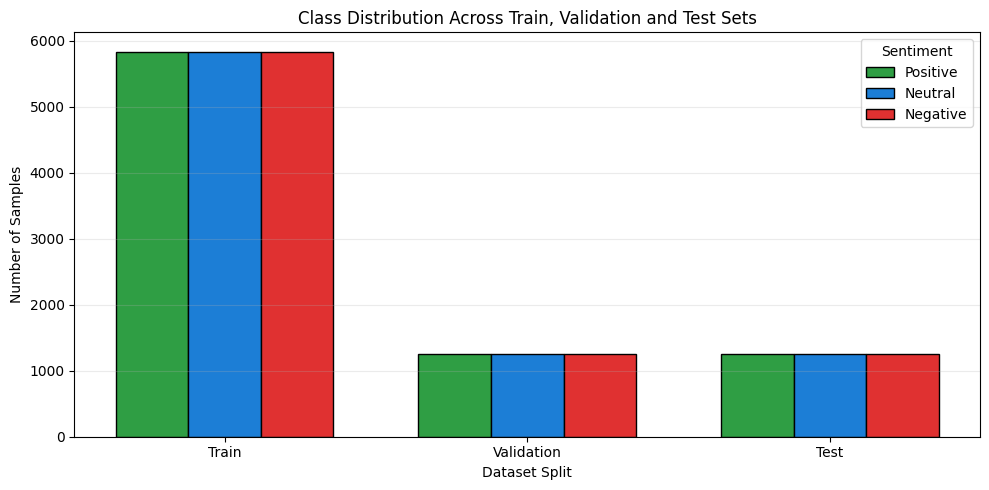

In [ ]:
X_train_texts, X_temp_texts, y_train, y_temp = train_test_split(
    X_texts,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val_texts, X_test_texts, y_val, y_test = train_test_split(
    X_temp_texts,
    y_temp,
    test_size=0.50,
    random_state=SEED,

    stratify=y_temp
)


splits = ["Train", "Validation", "Test"]

positive_counts = [
    np.bincount(y_train)[0],
    np.bincount(y_val)[0],
    np.bincount(y_test)[0]
]

negative_counts = [
    np.bincount(y_train)[1],
    np.bincount(y_val)[1],
    np.bincount(y_test)[1]
]

neutral_counts = [
    np.bincount(y_train)[2],
    np.bincount(y_val)[2],
    np.bincount(y_test)[2]
]

colors = {
    "positive": "#2F9E44",
    "neutral": "#1C7ED6",
    "negative": "#E03131"
}

x = np.arange(len(splits))
width = 0.24

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, positive_counts, width=width, label='Positive', color=colors["positive"], edgecolor='black')
ax.bar(x, neutral_counts, width=width, label='Neutral', color=colors["neutral"], edgecolor='black')
ax.bar(x + width, negative_counts, width=width, label='Negative', color=colors["negative"], edgecolor='black')

ax.set_title("Class Distribution Across Train, Validation and Test Sets")
ax.set_xlabel("Dataset Split")
ax.set_ylabel("Number of Samples")
ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.legend(title="Sentiment")
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()



The balanced dataset was divided into **training, validation, and test sets** using a stratified splitting strategy. First, the dataset was split into **70% training data** and **30% temporary data**. The temporary portion was then equally divided into **validation** and **test sets**, resulting in a final distribution of **70% training, 15% validation, and 15% test data**.

Stratified sampling was used to preserve the class distribution across all splits. As a result, each subset maintains a perfectly balanced distribution of the three sentiment classes. The training set contains **17,499 samples** (5,833 per class), while both the validation and test sets contain **3,750 samples** each (1,250 per class).

## Tokenization and Sequence Padding

In [ ]:
VOCAB_SIZE = 50000
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_texts)

train_seq = tokenizer.texts_to_sequences(X_train_texts)
val_seq   = tokenizer.texts_to_sequences(X_val_texts)
test_seq  = tokenizer.texts_to_sequences(X_test_texts)

lengths = np.array([len(s) for s in train_seq])

MAX_SEQUENCE_LEN = int(np.percentile(lengths, 95))
MAX_SEQUENCE_LEN = min(MAX_SEQUENCE_LEN, 256)
MAX_SEQUENCE_LEN = max(MAX_SEQUENCE_LEN, 50)

X_train = pad_sequences(
    train_seq,
    maxlen=MAX_SEQUENCE_LEN,
    padding="post",
    truncating="post"
).astype("int32")

X_val = pad_sequences(
    val_seq,
    maxlen=MAX_SEQUENCE_LEN,
    padding="post",
    truncating="post"
).astype("int32")

X_test = pad_sequences(
    test_seq,
    maxlen=MAX_SEQUENCE_LEN,
    padding="post",
    truncating="post"
).astype("int32")

y_train = y_train.astype("int32")
y_val   = y_val.astype("int32")
y_test  = y_test.astype("int32")

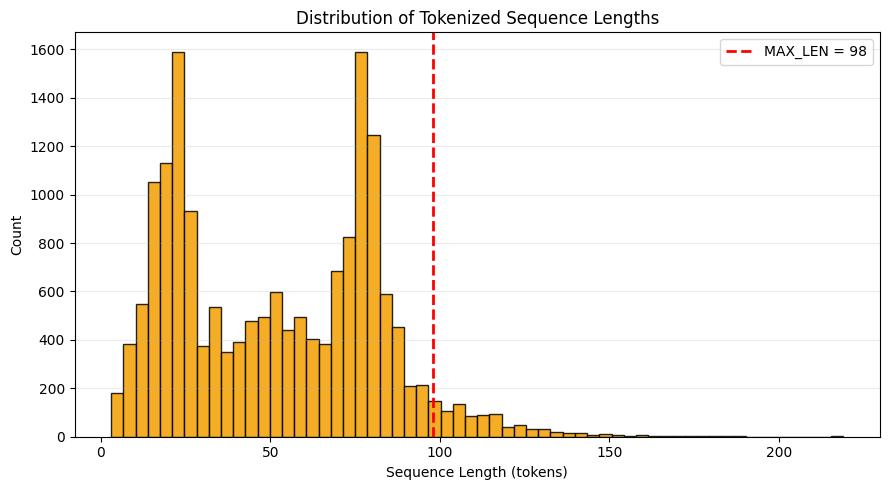

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(lengths, bins=60, color="#F59F00", edgecolor='black', alpha=0.85)
ax.axvline(
    MAX_SEQUENCE_LEN,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'MAX_LEN = {MAX_SEQUENCE_LEN}'
)

ax.set_title("Distribution of Tokenized Sequence Lengths")
ax.set_xlabel("Sequence Length (tokens)")
ax.set_ylabel("Count")
ax.legend()
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()



In this step, the textual data is converted into numerical sequences suitable for training the neural network. A **Tokenizer** is first initialized with a vocabulary size of **50,000 words** and an out-of-vocabulary token (`<OOV>`) to handle words that are not present in the vocabulary. The tokenizer is fitted on the training texts and then used to transform the training, validation, and test texts into sequences of integer indices representing words.

After tokenization, the length of each sequence in the training set is analyzed to determine an appropriate maximum sequence length. The **95th percentile** of the sequence lengths is used to set `MAX_SEQUENCE_LEN`, which results in a value of **98 tokens**. This means that **95% of the sequences contain 98 tokens or fewer**, while only the longest **5% of sequences exceed this length**.

Choosing the 95th percentile provides a good trade-off between preserving most of the textual information and reducing unnecessary padding. Using a much larger maximum length would introduce many padded tokens, increasing computational cost without providing additional useful information.

Finally, all sequences are padded or truncated to the same length using `pad_sequences`. Padding is applied at the end of the sequences (`padding="post"`), and sequences longer than the maximum length are truncated from the end (`truncating="post"`). This ensures that all input samples have the same fixed length, which is required for training the **BiLSTM model**.


## Saving Tokenizer and Configuration

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/Ds/bilstm_glove_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

tokenizer_json = tokenizer.to_json()
with open(os.path.join(SAVE_DIR, "tokenizer.json"), "w", encoding="utf-8") as f:
    f.write(tokenizer_json)

config = {
    "SEED": SEED,
    "VOCAB_SIZE": VOCAB_SIZE,
    "MAX_SEQUENCE_LEN": int(MAX_SEQUENCE_LEN),
    "OOV_TOKEN": OOV_TOKEN,
    "label_map": label_map
}

with open(os.path.join(SAVE_DIR, "config.json"), "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("Tokenizer and config saved in:", SAVE_DIR)

Tokenizer and config saved in: /content/drive/MyDrive/Ds/bilstm_glove_checkpoints


In this step, the tokenizer and the main preprocessing parameters are saved to ensure reproducibility of the experiment.

First, a directory is created to store the model artifacts and configuration files. The **tokenizer**, which contains the vocabulary and word–index mappings learned from the training data, is then converted into JSON format and saved. This allows the same tokenizer to be reused later during inference or when reloading the model, ensuring that new texts are processed in the same way as the training data.

In addition, a **configuration file** is created and saved as `config.json`. This file stores important parameters used during preprocessing and training, including the random seed, vocabulary size, maximum sequence length, the out-of-vocabulary token, and the label mapping used to encode sentiment classes.

## Loading GloVe Embeddings

In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2026-03-12 16:35:01--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-12 16:35:01--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-12 16:35:01--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
EMBED_DIM = 100
glove_path = "/content/glove.6B.100d.txt"

print("GloVe exists?", os.path.exists(glove_path))

embeddings_index = {}
with open(glove_path, encoding="utf8") as f:
    for line in f:
        values = line.rstrip().split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = coefs

print("Loaded GloVe vectors:", len(embeddings_index))

GloVe exists? True
Loaded GloVe vectors: 400000


In this step, **pre-trained GloVe word embeddings** are loaded in order to initialize the embedding layer of the BiLSTM model with semantic information learned from large external corpora.

First, the path to the **GloVe embedding file** (`glove.6B.100d.txt`) is defined and a check is performed to verify that the file exists in the specified location. These embeddings have a dimensionality of **100**, meaning that each word is represented by a vector of 100 numerical values.

The file is then read line by line. For each line, the first element corresponds to a **word**, while the remaining values represent its **embedding vector**. These vectors are converted into numerical arrays and stored in a dictionary (`embeddings_index`), where each word is mapped to its corresponding embedding vector.

Finally, the total number of loaded GloVe vectors is printed, confirming that the embeddings have been successfully loaded and are ready to be used for building the embedding matrix of the model.

To evaluate the usefulness of the pre-trained GloVe embeddings, we analyzed the coverage of the tokenizer vocabulary. The analysis shows the proportion of words in the dataset vocabulary that have a corresponding pre-trained embedding vector


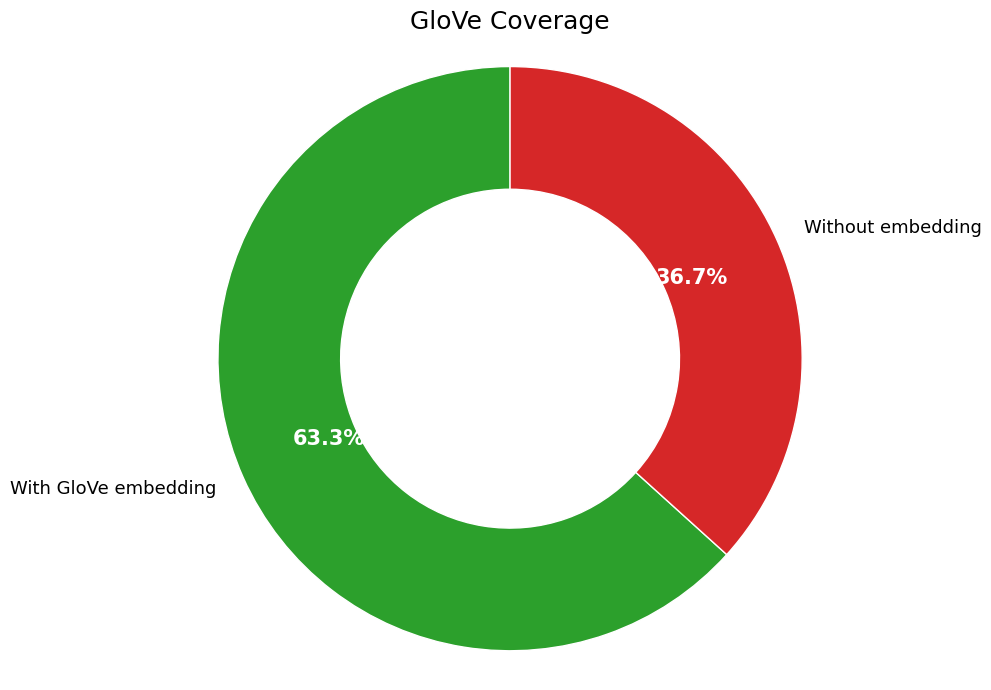

In [ ]:
labels = ['With GloVe embedding', 'Without embedding']
sizes = [63.3, 36.7]
colors = ['#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(9, 7))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    startangle=90,
    autopct='%1.1f%%',
    pctdistance=0.68,
    labeldistance=1.10,
    wedgeprops=dict(width=0.42, edgecolor='white'),
    textprops=dict(color='black', fontsize=13)
)

for t in autotexts:
    t.set_color('white')
    t.set_fontsize(15)
    t.set_fontweight('bold')
    t.set_ha('center')
    t.set_va('center')

ax.set_title('GloVe Coverage', fontsize=18)
ax.axis('equal')

plt.tight_layout()
plt.show()


The figure illustrates the coverage of the **pre-trained GloVe embeddings** over the vocabulary generated from the training dataset. The analysis shows that **31,481 words (63.3%)** from the tokenizer vocabulary have a corresponding vector in the GloVe embedding set, while **18,226 words (36.7%)** do not have a pre-trained embedding.

This indicates that a substantial portion of the dataset vocabulary can leverage semantic information learned from large external corpora through the GloVe embeddings. However, a significant number of words remain **out-of-vocabulary (OOV)** with respect to the GloVe model. These words are likely to include **domain-specific financial terms, company tickers, abbreviations, or rare expressions** that are not present in the original GloVe training corpus.



To further analyze the limitations of the pre-trained embeddings, we examined the most frequent words in the dataset that do not have a corresponding GloVe vector.

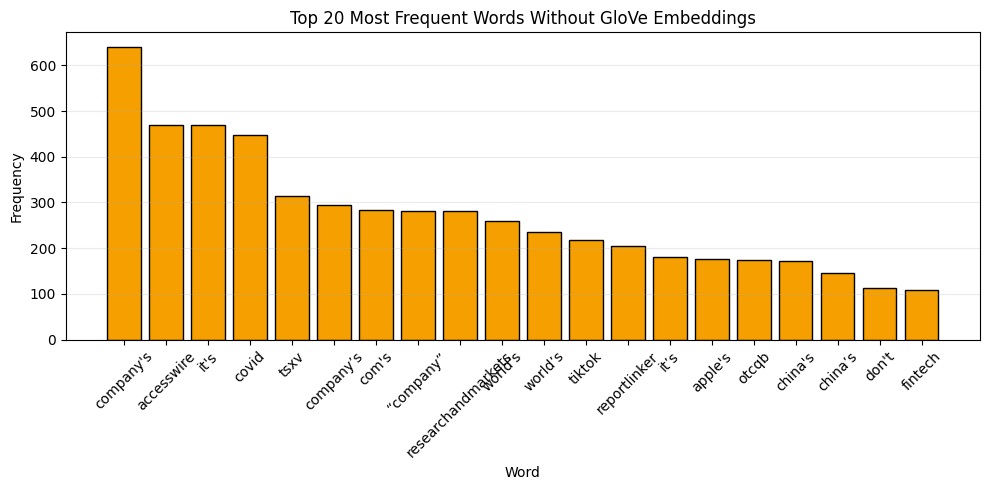

In [ ]:
word_index = tokenizer.word_index
word_counts = tokenizer.word_counts

oov_words = []

for word, count in word_counts.items():
    if word not in embeddings_index:
        oov_words.append((word, count))

oov_df = pd.DataFrame(oov_words, columns=["word", "count"])

top_oov = (
    oov_df
    .sort_values("count", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top_oov["word"], top_oov["count"], color="#F59F00", edgecolor='black')
ax.set_title("Top 20 Most Frequent Words Without GloVe Embeddings")
ax.set_xlabel("Word")
ax.set_ylabel("Frequency")
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()



## Building the Embedding Matrix

In [ ]:
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM), dtype="float32")

for word, i in tokenizer.word_index.items():
    if i >= VOCAB_SIZE:
        continue
    vec = embeddings_index.get(word)
    if vec is not None:
        embedding_matrix[i] = vec

In this step, the **embedding matrix** used by the neural network is constructed from the pre-trained GloVe vectors. First, an empty matrix of size **(VOCAB_SIZE × EMBED_DIM)** is initialized with zeros. Each row of this matrix will correspond to the vector representation of a word in the tokenizer vocabulary.

The code then iterates over the **word–index mapping** generated by the tokenizer. For each word, its corresponding index is checked to ensure that it falls within the defined vocabulary size. If the word exists in the GloVe embedding dictionary, its pre-trained vector is retrieved and placed in the corresponding row of the embedding matrix.

As a result, words that have a matching GloVe embedding receive their **pre-trained vector representation**, while words that are not present in the GloVe vocabulary remain as **zero vectors** in the matrix. This embedding matrix is later used to initialize the **embedding layer of the BiLSTM model**.


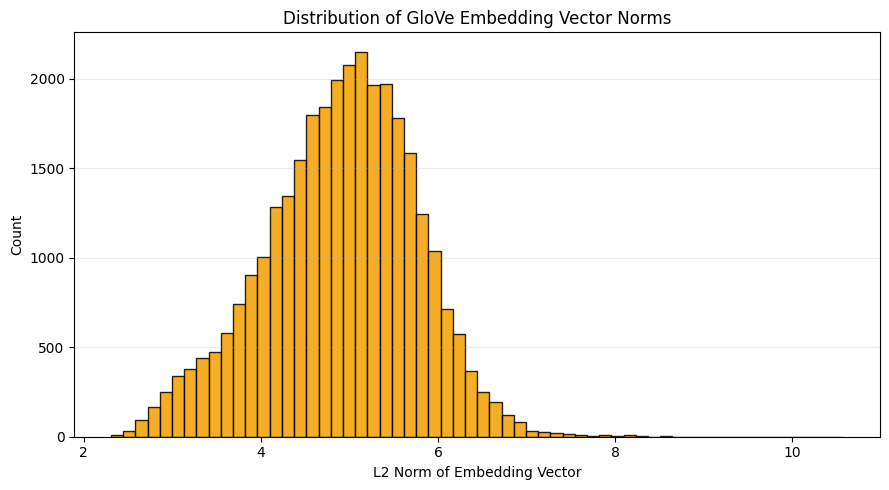

In [ ]:
norms = np.linalg.norm(embedding_matrix, axis=1)

norms_nonzero = norms[norms > 0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(norms_nonzero, bins=60, color="#F59F00", edgecolor='black', alpha=0.85)
ax.set_title("Distribution of GloVe Embedding Vector Norms")
ax.set_xlabel("L2 Norm of Embedding Vector")
ax.set_ylabel("Count")
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()



The figure shows the distribution of the **L2 norms of the pre-trained GloVe embeddings** used to initialize the embedding matrix. Most vectors have norms between **4 and 6**, indicating a consistent magnitude typical of GloVe embeddings.

Since the **embedding layer is frozen**, these vectors remain unchanged during training and provide fixed semantic representations for the corresponding words in the vocabulary.


## BiLSTM Model Architecture

In [ ]:
def build_bilstm_model(vocab_size, embed_dim, embedding_matrix,
                       max_sequence_len,
                       lstm_units, dense_units, dropout_rate, learning_rate):

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)

    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            weights=[embedding_matrix],
            trainable=False,
            mask_zero=True
        ),
        SpatialDropout1D(dropout_rate),
        Bidirectional(LSTM(lstm_units, dropout=dropout_rate)),
        Dense(dense_units),
        LeakyReLU(negative_slope=0.1),
        Dropout(dropout_rate),
        Dense(3, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.build(input_shape=(None, max_sequence_len))
    return model

In [ ]:
reference_model = build_bilstm_model(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    embedding_matrix=embedding_matrix,
    max_sequence_len=MAX_SEQUENCE_LEN,
    lstm_units=64,
    dense_units=64,
    dropout_rate=0.3,
    learning_rate=1e-3
)

reference_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 98, 100)        │     5,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 98, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,092,931 (19.43 MB)

 Trainable params: 92,931 (363.01 KB)

 Non-trainable params: 5,000,000 (19.07 MB)

This function defines the architecture of the **Bidirectional LSTM (BiLSTM) model** used for sentiment classification. At the beginning, the TensorFlow session and random seeds are reset to ensure **reproducibility of the experiments**.

The model starts with an **Embedding layer** initialized using the pre-trained **GloVe embedding matrix**. The embedding layer is **frozen (`trainable=False`)**, meaning that the pre-trained vectors remain unchanged during training. The parameter `mask_zero=True` allows the model to ignore padding tokens introduced during sequence preprocessing.

A **SpatialDropout1D layer** is then applied to randomly drop entire embedding features during training, helping to reduce overfitting. The main sequence modeling component is a **Bidirectional LSTM layer**, which processes the text in both forward and backward directions to capture contextual information from the entire sentence.

The output of the BiLSTM layer is passed to a **dense hidden layer**, followed by a **LeakyReLU activation function** and a **Dropout layer** for additional regularization. Finally, a **Dense output layer with softmax activation** is used to predict the probabilities of the three sentiment classes.

The model is compiled using the **Adam optimizer**, with the learning rate treated as a tunable hyperparameter. The **sparse categorical cross-entropy** loss function is used since the sentiment labels are encoded as integer values, and **accuracy** is used as the evaluation metric.


## Tuning configuration

In [ ]:
TUNING_DIR = "/content/drive/MyDrive/Ds/bilstm_glove_gridsearch"
os.makedirs(TUNING_DIR, exist_ok=True)

SEARCH_EPOCHS = 7
FINAL_EPOCHS = 20
BATCH_SIZE = 32

LSTM_UNITS_LIST = [32, 64, 96]
DENSE_UNITS_LIST = [32, 64, 128]
DROPOUT_LIST = [0.2, 0.3, 0.4]
LEARNING_RATE_LIST = [1e-3, 5e-4, 2e-4]

RESULTS_CSV = os.path.join(TUNING_DIR, "grid_search_results.csv")
BEST_CONFIG_JSON = os.path.join(TUNING_DIR, "best_config.json")

print("Tuning directory:", TUNING_DIR)
print("Total combinations:", len(LSTM_UNITS_LIST) * len(DENSE_UNITS_LIST) * len(DROPOUT_LIST) * len(LEARNING_RATE_LIST))

Tuning directory: /content/drive/MyDrive/Ds/bilstm_glove_gridsearch
Total combinations: 81


In this step, the environment for the **hyperparameter tuning process** of the BiLSTM model is prepared. A directory is first created to store the results of the tuning procedure, including performance metrics and the best configuration found during the search.

Several hyperparameters that influence the model architecture and training process are defined. These include the number of **LSTM units**, the size of the **dense layer**, the **dropout rate**, and the **learning rate**. Multiple values are specified for each parameter, allowing the model to be evaluated across different configurations.

A **grid search strategy** is used, where all possible combinations of these hyperparameters are explored. The script also defines the number of epochs used during the search phase and during the final training phase. Finally, file paths are specified to store the results of the grid search and the configuration of the best-performing model.


## Hyperparameter Grid Construction

In [ ]:
param_grid = list(itertools.product(
    LSTM_UNITS_LIST,
    DENSE_UNITS_LIST,
    DROPOUT_LIST,
    LEARNING_RATE_LIST
))

grid_df = pd.DataFrame(param_grid, columns=[
    "lstm_units",
    "dense_units",
    "dropout_rate",
    "learning_rate"
])

grid_df["trial_id"] = [f"trial_{i+1:03d}" for i in range(len(grid_df))]
grid_df = grid_df[["trial_id", "lstm_units", "dense_units", "dropout_rate", "learning_rate"]]

print(grid_df.head())
print("Number of trials:", len(grid_df))

    trial_id  lstm_units  dense_units  dropout_rate  learning_rate
0  trial_001          32           32           0.2         0.0010
1  trial_002          32           32           0.2         0.0005
2  trial_003          32           32           0.2         0.0002
3  trial_004          32           32           0.3         0.0010
4  trial_005          32           32           0.3         0.0005
Number of trials: 81


In this step, all possible combinations of the selected hyperparameters are generated using a **grid search approach**. The Cartesian product of the predefined values for the number of LSTM units, dense layer units, dropout rate, and learning rate is computed to create the full set of configurations to be tested.

These combinations are then stored in a **Pandas DataFrame**, where each row represents a different trial. A unique **trial identifier (`trial_id`)** is also assigned to each configuration to facilitate tracking and comparison of results during the tuning process. Finally, the total number of trials is printed to indicate how many model configurations will be evaluated.


## Loading Previous Grid Search Results

In [ ]:
if os.path.exists(RESULTS_CSV):
    results_df = pd.read_csv(RESULTS_CSV)
    completed_trials = set(results_df["trial_id"].astype(str).tolist())
    print(f"Found existing results file with {len(completed_trials)} completed trials.")
else:
    results_df = pd.DataFrame()
    completed_trials = set()
    print("No previous results found. Starting from scratch.")

Found existing results file with 81 completed trials.


This code checks whether a file containing the results of previous grid search experiments already exists. If the file is found, it is loaded into a DataFrame and the identifiers of the completed trials are extracted. This allows the script to keep track of which configurations have already been evaluated and avoid repeating them.

If no results file is found, an empty DataFrame is created and the set of completed trials is initialized as empty. In this case, the hyperparameter search starts from scratch.


## Grid Search Training Loop

In [ ]:
all_results = []

if os.path.exists(RESULTS_CSV):
    all_results = pd.read_csv(RESULTS_CSV).to_dict("records")

for _, row in grid_df.iterrows():
    trial_id = row["trial_id"]

    if trial_id in completed_trials:
        print(f"Skipping {trial_id} (already completed).")
        continue

    lstm_units = int(row["lstm_units"])
    dense_units = int(row["dense_units"])
    dropout_rate = float(row["dropout_rate"])
    learning_rate = float(row["learning_rate"])

    print("\n" + "=" * 100)
    print(f"Starting {trial_id}")
    print(f"lstm_units={lstm_units}, dense_units={dense_units}, dropout_rate={dropout_rate}, learning_rate={learning_rate}")
    print("=" * 100)

    trial_dir = os.path.join(TUNING_DIR, trial_id)
    os.makedirs(trial_dir, exist_ok=True)

    trial_log_path = os.path.join(trial_dir, "training_log.csv")
    trial_model_path = os.path.join(trial_dir, "best_model.keras")
    trial_result_path = os.path.join(trial_dir, "result.json")

    model = build_bilstm_model(
        vocab_size=VOCAB_SIZE,
        embed_dim=EMBED_DIM,
        embedding_matrix=embedding_matrix,
        max_sequence_len=MAX_SEQUENCE_LEN,
        lstm_units=lstm_units,
        dense_units=dense_units,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate
    )

    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=trial_model_path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=False,
            verbose=0
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-5,
            verbose=1
        ),
        CSVLogger(trial_log_path, append=False)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=SEARCH_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    best_epoch_idx = int(np.argmin(history.history["val_loss"]))
    best_val_loss = float(history.history["val_loss"][best_epoch_idx])
    best_val_acc = float(history.history["val_accuracy"][best_epoch_idx])
    best_train_loss = float(history.history["loss"][best_epoch_idx])
    best_train_acc = float(history.history["accuracy"][best_epoch_idx])
    epochs_ran = len(history.history["loss"])

    result = {
        "trial_id": trial_id,
        "lstm_units": lstm_units,
        "dense_units": dense_units,
        "dropout_rate": dropout_rate,
        "learning_rate": learning_rate,
        "best_epoch": best_epoch_idx + 1,
        "epochs_ran": epochs_ran,
        "best_val_loss": best_val_loss,
        "best_val_accuracy": best_val_acc,
        "best_train_loss": best_train_loss,
        "best_train_accuracy": best_train_acc,
        "model_path": trial_model_path
    }

    with open(trial_result_path, "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2)

    all_results.append(result)
    pd.DataFrame(all_results).to_csv(RESULTS_CSV, index=False)

    print(f"Completed {trial_id}")
    print(f"Best epoch: {result['best_epoch']}")
    print(f"Best val_loss: {best_val_loss:.4f}")
    print(f"Best val_accuracy: {best_val_acc:.4f}")

Skipping trial_001 (already completed).
Skipping trial_002 (already completed).
Skipping trial_003 (already completed).
Skipping trial_004 (already completed).
Skipping trial_005 (already completed).
Skipping trial_006 (already completed).
Skipping trial_007 (already completed).
Skipping trial_008 (already completed).
Skipping trial_009 (already completed).
Skipping trial_010 (already completed).
Skipping trial_011 (already completed).
Skipping trial_012 (already completed).
Skipping trial_013 (already completed).
Skipping trial_014 (already completed).
Skipping trial_015 (already completed).
Skipping trial_016 (already completed).
Skipping trial_017 (already completed).
Skipping trial_018 (already completed).
Skipping trial_019 (already completed).
Skipping trial_020 (already completed).
Skipping trial_021 (already completed).
Skipping trial_022 (already completed).
Skipping trial_023 (already completed).
Skipping trial_024 (already completed).
Skipping trial_025 (already completed).


This code implements the **grid search procedure** used to tune the hyperparameters of the BiLSTM model. The script iterates over all configurations defined in the hyperparameter grid and trains a model for each trial.

Before starting a new trial, the code checks whether that configuration has already been completed in a previous run. If so, the trial is skipped to avoid redundant computation. For each new configuration, a dedicated directory is created to store the training logs, the best model checkpoint, and the final results.

The model is then built using the selected hyperparameters and trained on the training set while being evaluated on the validation set. Several **callbacks** are used during training: `ModelCheckpoint` saves the best model according to the validation loss, `EarlyStopping` stops training if the validation performance stops improving, `ReduceLROnPlateau` reduces the learning rate when validation loss stagnates, and `CSVLogger` records the training history.

After training, the best epoch is identified based on the **minimum validation loss**, and key metrics such as validation accuracy, training accuracy, and losses are extracted. These results are saved in a JSON file for each trial and appended to a global results file. This allows the grid search to be **tracked, resumed, and analyzed efficiently**.


## Grid Search Results

In [ ]:
ranked_df = results_df.sort_values(
    by=["best_val_loss", "best_val_accuracy"],
    ascending=[True, False]
).reset_index(drop=True)

ranked_df["rank"] = np.arange(1, len(ranked_df) + 1)

cols = ["rank"] + [c for c in ranked_df.columns if c != "rank"]
ranked_df = ranked_df[cols]

display(ranked_df.head(10).style.hide(axis="index"))

rank,trial_id,lstm_units,dense_units,dropout_rate,learning_rate,best_epoch,epochs_ran,best_val_loss,best_val_accuracy,best_train_loss,best_train_accuracy,model_path
1,trial_063,96,64,0.200000,0.001000,7,7,0.870568,0.593600,0.822310,0.624779,/content/drive/MyDrive/Ds/bilstm_glove_gridsearch/trial_063/best_model.keras
2,trial_054,96,32,0.200000,0.001000,7,7,0.872466,0.601067,0.828424,0.618892,/content/drive/MyDrive/Ds/bilstm_glove_gridsearch/trial_054/best_model.keras
3,trial_057,96,32,0.300000,0.001000,7,7,0.873686,0.596800,0.884944,0.589577,/content/drive/MyDrive/Ds/bilstm_glove_gridsearch/trial_057/best_model.keras
4,trial_066,96,64,0.300000,0.001000,7,7,0.874705,0.590133,0.878740,0.587634,/content/drive/MyDrive/Ds/bilstm_glove_gridsearch/trial_066/best_model.keras
5,trial_000,32,32,0.200000,0.001000,7,7,0.874720,0.598400,0.867817,0.598320,/content/drive/MyDrive/Ds/bilstm_glove_gridsearch/trial_000/best_model.keras
6,trial_027,64,32,0.200000,0.001000,7,7,0.875361,0.596800,0.844175,0.614664,/content/drive/MyDrive/Ds/bilstm_glove_gridsearch/trial_027/best_model.keras
7,trial_018,32,128,0.200000,0.001000,7,7,0.876380,0.592267,0.857795,0.603063,/content/drive/MyDrive/Ds/bilstm_glove_gridsearch/trial_018/best_model.keras
8,trial_045,64,128,0.200000,0.001000,7,7,0.876390,0.598933,0.834379,0.621293,/content/drive/MyDrive/Ds/bilstm_glove_gridsearch/trial_045/best_model.keras
9,trial_055,96,32,0.200000,0.000500,7,7,0.877448,0.591733,0.869693,0.594891,/content/drive/MyDrive/Ds/bilstm_glove_gridsearch/trial_055/best_model.keras
10,trial_009,32,64,0.200000,0.001000,7,7,0.877608,0.593067,0.862897,0.606720,/content/drive/MyDrive/Ds/bilstm_glove_gridsearch/trial_009/best_model.keras


The results of the hyperparameter grid search were ranked according to **validation loss**, with **validation accuracy used as a secondary criterion** in case of ties. The table shows the top-performing configurations among the tested combinations.

The best configuration corresponds to **trial_063**, which achieved the lowest validation loss (**0.8706**) with a validation accuracy of **59.36%**. This model uses **96 LSTM units, 64 dense units, a dropout rate of 0.2, and a learning rate of 0.001**.

Overall, the top-ranked configurations share several common characteristics. In particular, models with **larger LSTM layers (96 units)** tend to perform better, suggesting that a higher-capacity recurrent layer helps capture contextual information in financial news texts. Additionally, the best-performing models consistently use a **dropout rate of 0.2**, indicating that stronger regularization may slightly hinder performance.

The learning rate of **0.001** also appears frequently among the highest-ranked trials, suggesting that it provides a good balance between training stability and convergence speed.

Based on these results, the best-performing configuration is selected for the **final training phase**, where the model will be trained for a larger number of epochs before being evaluated on the test set.


## Best Configuration Selection

In [ ]:
best_row = ranked_df.iloc[0].to_dict()

with open(BEST_CONFIG_JSON, "w", encoding="utf-8") as f:
    json.dump(best_row, f, indent=2)

print("Best configuration selected automatically:")
print(json.dumps(best_row, indent=2))

Best configuration selected automatically:
{
  "rank": 1,
  "trial_id": "trial_063",
  "lstm_units": 96,
  "dense_units": 64,
  "dropout_rate": 0.2,
  "learning_rate": 0.001,
  "best_epoch": 7,
  "epochs_ran": 7,
  "best_val_loss": 0.8705682158470154,
  "best_val_accuracy": 0.5935999751091003,
  "best_train_loss": 0.8223101496696472,
  "best_train_accuracy": 0.6247785687446594,
  "model_path": "/content/drive/MyDrive/Ds/bilstm_glove_gridsearch/trial_063/best_model.keras"
}


In this step, the best-performing configuration from the grid search results is automatically selected. The top-ranked row of the results table is extracted and converted into a dictionary containing the optimal hyperparameter values and associated performance metrics. This configuration is then saved to a **JSON file**, allowing it to be easily reused for the final training phase or future experiments.

## Final Model Training


In [ ]:
with open(BEST_CONFIG_JSON, "r", encoding="utf-8") as f:
    best_config = json.load(f)

best_lstm_units = int(best_config["lstm_units"])
best_dense_units = int(best_config["dense_units"])
best_dropout_rate = float(best_config["dropout_rate"])
best_learning_rate = float(best_config["learning_rate"])

print("Best hyperparameters:")
print(best_config)

final_model = build_bilstm_model(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    embedding_matrix=embedding_matrix,
    max_sequence_len=MAX_SEQUENCE_LEN,
    lstm_units=best_lstm_units,
    dense_units=best_dense_units,
    dropout_rate=best_dropout_rate,
    learning_rate=best_learning_rate
)

FINAL_MODEL_DIR = os.path.join(TUNING_DIR, "final_best_model")
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)

final_model_path = os.path.join(FINAL_MODEL_DIR, "best_final_model.keras")
final_log_path = os.path.join(FINAL_MODEL_DIR, "final_training_log.csv")

final_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=final_model_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1
    ),
    CSVLogger(final_log_path, append=False)
]

final_history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=FINAL_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=final_callbacks,
    verbose=1
)

Best hyperparameters:
{'rank': 1, 'trial_id': 'trial_063', 'lstm_units': 96, 'dense_units': 64, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'best_epoch': 7, 'epochs_ran': 7, 'best_val_loss': 0.8705682158470154, 'best_val_accuracy': 0.5935999751091003, 'best_train_loss': 0.8223101496696472, 'best_train_accuracy': 0.6247785687446594, 'model_path': '/content/drive/MyDrive/Ds/bilstm_glove_gridsearch/trial_063/best_model.keras'}
Epoch 1/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4565 - loss: 1.0356
Epoch 1: val_loss improved from inf to 0.94054, saving model to /content/drive/MyDrive/Ds/bilstm_glove_gridsearch/final_best_model/best_final_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.4566 - loss: 1.0355 - val_accuracy: 0.5469 - val_loss: 0.9405 - learning_rate: 0.0010
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5410 - loss: 0.9444
Epoch 2: val_loss improved from 0.94054 to 0.90969, saving model to /content/drive/MyDrive/Ds/bilstm

In this step, the **best hyperparameter configuration** identified during the grid search is loaded from the saved JSON file. The selected values for the number of LSTM units, dense layer units, dropout rate, and learning rate are extracted and used to rebuild the BiLSTM model.

A new directory is then created to store the artifacts related to the **final model training**, including the trained model and the training logs. The model is trained again using the full training set with the optimal hyperparameters and a larger number of epochs.

Several callbacks are used during training. `ModelCheckpoint` saves the best version of the model based on validation loss, `EarlyStopping` prevents overfitting by stopping training when validation performance stops improving, `ReduceLROnPlateau` dynamically reduces the learning rate if validation loss stagnates, and `CSVLogger` records the training history for later analysis.

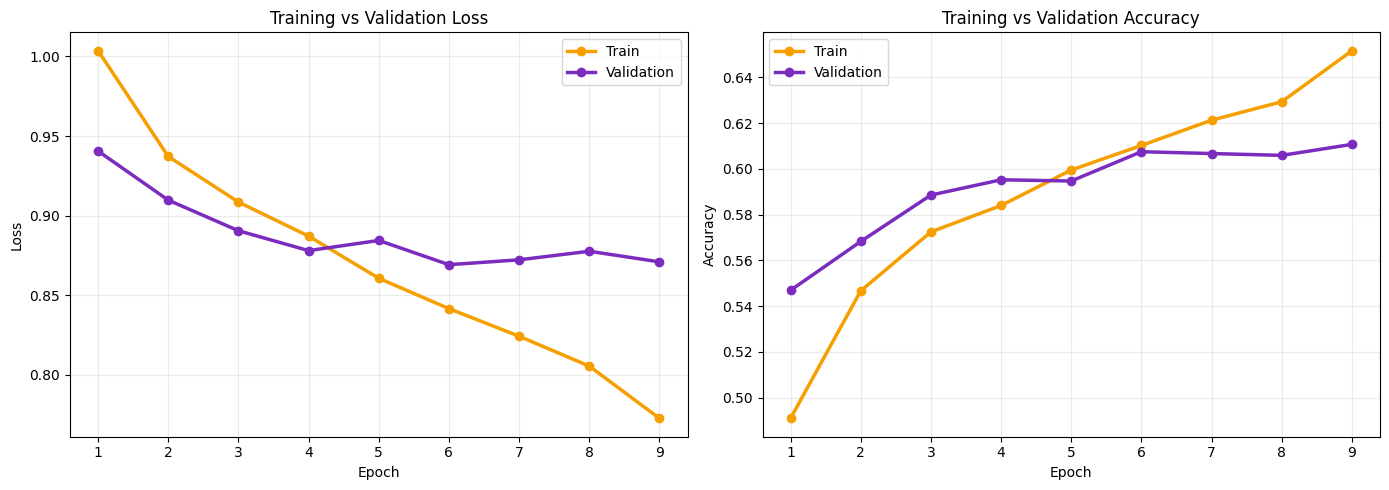

In [ ]:
log_df = pd.read_csv(final_log_path)
epochs = (log_df["epoch"] + 1).tolist()
train_loss = log_df["loss"].tolist()
val_loss = log_df["val_loss"].tolist()
train_acc = log_df["accuracy"].tolist()
val_acc = log_df["val_accuracy"].tolist()

train_color = "#F59F00"
val_color = "#7B2CBF"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, train_loss, marker='o', linewidth=2.5, color=train_color, label='Train')
axes[0].plot(epochs, val_loss, marker='o', linewidth=2.5, color=val_color, label='Validation')
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(epochs, train_acc, marker='o', linewidth=2.5, color=train_color, label='Train')
axes[1].plot(epochs, val_acc, marker='o', linewidth=2.5, color=val_color, label='Validation')
axes[1].set_title("Training vs Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()



As training progresses, the **training loss decreases steadily**, indicating that the model effectively learns patterns from the training data. The **validation loss initially decreases and then stabilizes after approximately epoch 5**, suggesting that the model reaches a stable generalization performance in the later stages of training.

A similar trend can be observed in the accuracy curves. The **training accuracy increases consistently**, reaching approximately **0.65** at the final epoch, while the **validation accuracy gradually improves and stabilizes around 0.61**. The difference between training and validation accuracy remains relatively small (about **0.04**), which indicates that the model maintains good generalization and does not exhibit overfitting.


## Model Evaluation on the Test Set

In [ ]:
TUNING_DIR = "/content/drive/MyDrive/Ds/bilstm_glove_gridsearch"
FINAL_MODEL_DIR = os.path.join(TUNING_DIR, "final_best_model")
final_model_path = os.path.join(FINAL_MODEL_DIR, "best_final_model.keras")

final_model = load_model(final_model_path)

This block is used only when the notebook is reopened and the previous training steps are not executed again. It reloads the best trained model saved during the training phase and generates predictions on the test set, allowing the final evaluation and visualization steps to be performed directly without repeating the full training process.

In [ ]:
test_loss, test_acc = final_model.evaluate(X_test, y_test, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

class_names = ["negative", "neutral", "positive"]

y_pred_prob = final_model.predict(X_test)
y_test_pred = np.argmax(y_pred_prob, axis=1)

report = classification_report(
    y_test,
    y_test_pred,
    target_names=class_names
)

print(report)

118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6230 - loss: 0.8531
Test Loss: 0.8516
Test Accuracy: 0.6173
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

    negative       0.57      0.60      0.58      1250
     neutral       0.67      0.59      0.63      1250
    positive       0.61      0.66      0.64      1250

    accuracy                           0.62      3750
   macro avg       0.62      0.62      0.62      3750
weighted avg       0.62      0.62      0.62      3750



The final BiLSTM model was evaluated on the **held-out test set** to assess its generalization performance. The model achieved a **test accuracy of 0.617** with a **test loss of 0.852**, indicating a consistent performance compared to the validation results observed during training.

The classification report provides a more detailed view of the model's performance across the three sentiment classes (**negative, neutral, and positive**). The model achieves **precision, recall, and F1-scores in the range of approximately 0.58–0.64**, showing relatively balanced performance across the classes.

In particular, the **positive class** obtains the highest recall (0.66) and the highest F1-score (0.64), indicating that the model is slightly better at identifying positive news articles. The **neutral class** achieves the highest precision (0.67), suggesting that when the model predicts a neutral sentiment, it is often correct. The **negative class** shows slightly lower metrics overall, with an F1-score of 0.58.

The **macro-average F1-score of 0.62** indicates that the model performs consistently across all sentiment categories without strong bias toward any specific class. Given the balanced dataset and the complexity of financial sentiment analysis, these results suggest that the BiLSTM model is able to capture meaningful patterns in financial news text while maintaining stable performance across sentiment categories.


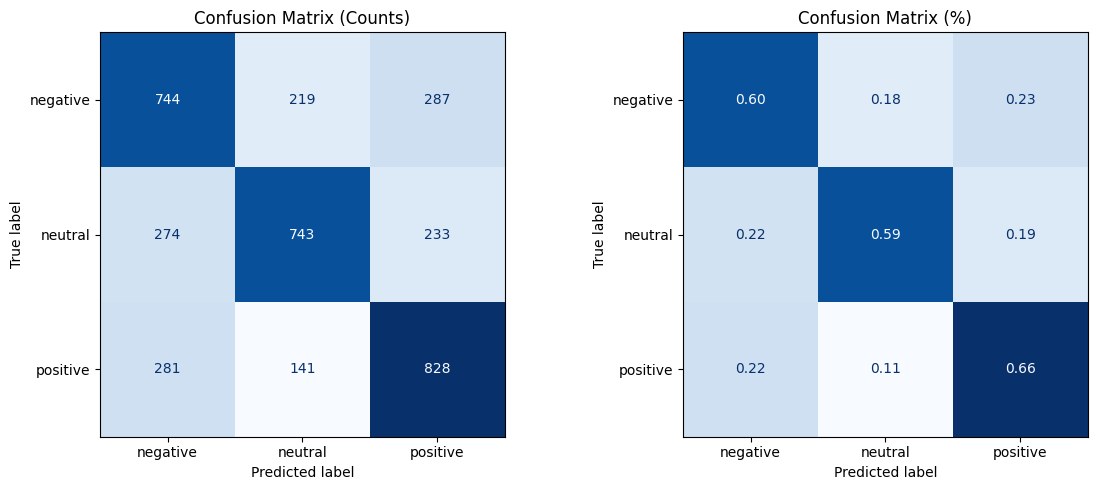

In [ ]:
# Confusion matrix (counts)
cm = confusion_matrix(y_test, y_test_pred)

# Normalized confusion matrix
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

# Create figure with two plots
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Count matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix (Counts)")

# Percentage matrix
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp_norm.plot(cmap="Blues", ax=axes[1], values_format=".2f", colorbar=False)
axes[1].set_title("Confusion Matrix (%)")

plt.tight_layout()
plt.show()

The confusion matrix provides a detailed view of the classification performance of the BiLSTM model on the test set by showing how many samples from each true class are assigned to each predicted class.

The model correctly classifies **744 negative**, **743 neutral**, and **828 positive** samples. The **positive class shows the highest number of correct predictions**, which is consistent with the slightly higher recall and F1-score observed for this class in the classification report.

Some misclassifications occur between neighboring sentiment categories. In particular, a notable number of **negative samples are predicted as neutral (219)** or **positive (287)**, suggesting that distinguishing clearly negative financial news from more neutral or mildly positive content can be challenging. Similarly, **neutral samples are sometimes misclassified as negative (274)** or positive (233), reflecting the inherent ambiguity often present in neutral financial news.

For the **positive class**, most predictions are correct, although a portion of positive samples is predicted as negative (281) or neutral (141). Overall, the confusion matrix confirms that while the model achieves balanced performance across classes, some overlap remains between sentiment categories, which is expected given the subtle linguistic differences often found in financial news sentiment.


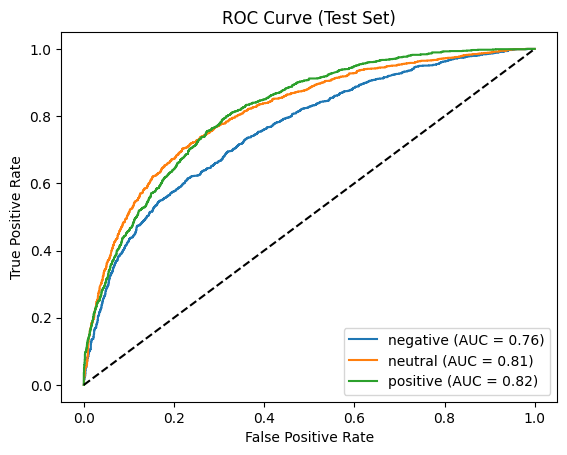

In [ ]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

n_classes = 3

plt.figure()

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_pred_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC = {roc_auc:.2f})"
    )

plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend()
plt.show()

The model achieves an **AUC of 0.76 for the negative class**, **0.81 for the neutral class**, and **0.82 for the positive class**. These values indicate that the model has a good ability to separate the sentiment categories, with the best performance observed for the **positive and neutral classes**.

The curve for the **negative class** is slightly closer to the diagonal baseline compared to the others, suggesting that distinguishing negative financial news from other sentiments is somewhat more challenging for the model. This observation is consistent with the confusion matrix, where negative samples show a higher rate of misclassification.

The ROC analysis confirms that the model performs significantly better than random guessing and demonstrates a **reasonable discriminative capability across all sentiment classes**, with stronger separability for positive and neutral sentiments.


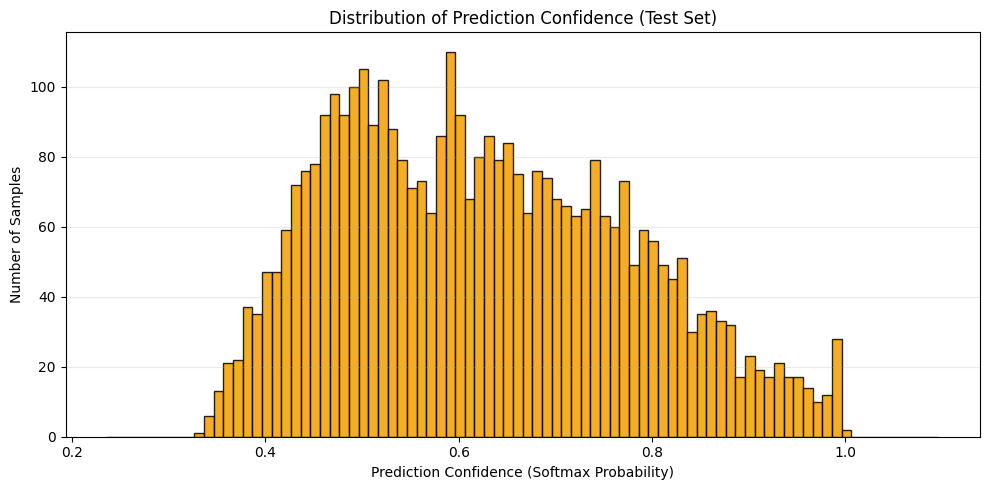

In [ ]:
confidence_scores = np.max(y_pred_prob, axis=1)

bins = np.arange(confidence_scores.min() - 0.1, 1 + 0.1, 0.01)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(confidence_scores, bins=bins, color="#F59F00", edgecolor='black', alpha=0.85)

ax.set_title("Distribution of Prediction Confidence (Test Set)")
ax.set_xlabel("Prediction Confidence (Softmax Probability)")
ax.set_ylabel("Number of Samples")
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()



The histogram illustrates the distribution of the model’s **prediction confidence** on the test set, measured as the **maximum softmax probability** assigned to the predicted class for each sample.

Most predictions fall within the **0.5–0.8 confidence range**, suggesting that the model often produces moderately confident predictions rather than extremely high-confidence ones. Only a smaller portion of samples reaches very high confidence values (above 0.9), indicating that strongly decisive predictions are relatively limited.

The presence of predictions with lower confidence values (around **0.35–0.5**) suggests that some news articles present ambiguous sentiment cues, making them more difficult to classify. This behavior is expected in financial news sentiment analysis, where the distinction between neutral, positive, and negative sentiment can be subtle.

Overall, the distribution indicates that the model maintains a reasonable level of confidence across predictions while reflecting the inherent uncertainty present in real-world financial text data.


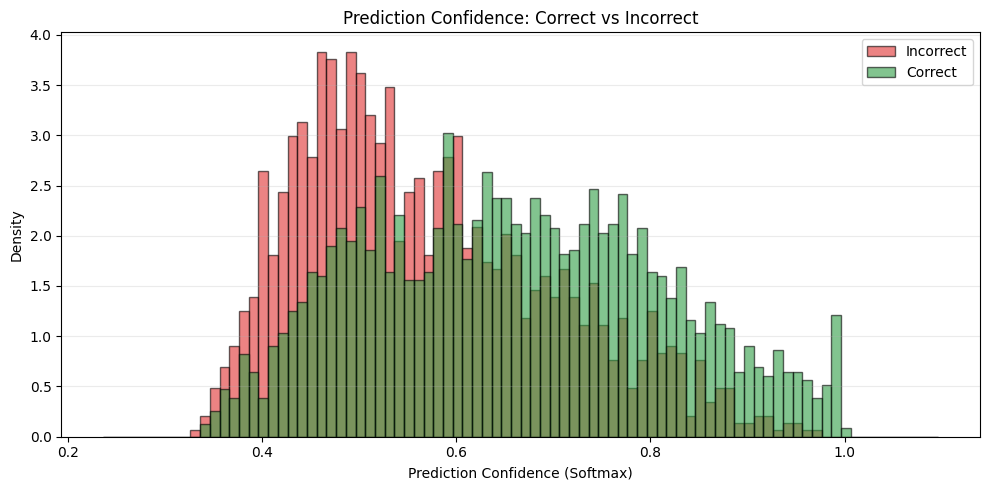

In [ ]:
confidence_scores = np.max(y_pred_prob, axis=1)
correct_mask = (y_test_pred == y_test)

correct_conf = confidence_scores[correct_mask]
incorrect_conf = confidence_scores[~correct_mask]

bins = np.arange(confidence_scores.min() - 0.1, 1 + 0.1, 0.01)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    incorrect_conf,
    bins=bins,
    density=True,
    alpha=0.60,
    label='Incorrect',
    color="#E03131",
    edgecolor='black'
)
ax.hist(
    correct_conf,
    bins=bins,
    density=True,
    alpha=0.60,
    label='Correct',
    color="#2F9E44",
    edgecolor='black'
)

ax.set_title("Prediction Confidence: Correct vs Incorrect")
ax.set_xlabel("Prediction Confidence (Softmax)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()



The figure shows the distribution of prediction confidence for correctly and incorrectly classified samples in the test set. Correct predictions generally occur at higher confidence values, with a clear concentration above approximately 0.6. In contrast, incorrect predictions are more frequent at lower confidence levels, particularly between 0.4 and 0.6. Although the two distributions partially overlap, the overall shift toward higher confidence for correct predictions suggests that the model’s confidence scores provide a useful indication of prediction reliability.


/tmp/ipykernel_217/2088198188.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


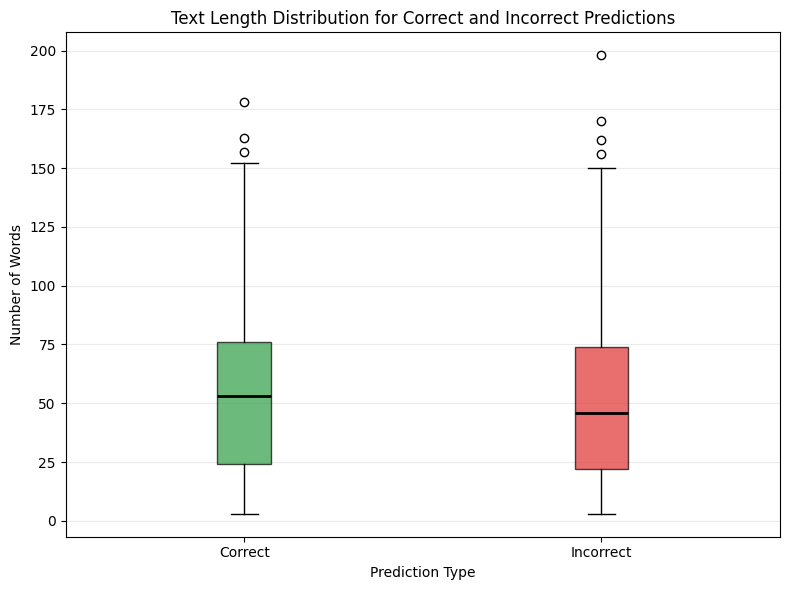

In [ ]:
text_lengths = [len(str(t).split()) for t in X_test_texts]

correct = (y_test_pred == y_test)

df_length = pd.DataFrame({
    "Text Length": text_lengths,
    "Prediction": np.where(correct, "Correct", "Incorrect")
})

fig, ax = plt.subplots(figsize=(8, 6))

data_to_plot = [
    df_length[df_length["Prediction"] == "Correct"]["Text Length"],
    df_length[df_length["Prediction"] == "Incorrect"]["Text Length"]
]

box = ax.boxplot(
    data_to_plot,
    labels=["Correct", "Incorrect"],
    patch_artist=True
)

box["boxes"][0].set(facecolor="#2F9E44", alpha=0.7)
box["boxes"][1].set(facecolor="#E03131", alpha=0.7)

for median in box["medians"]:
    median.set(color="black", linewidth=2)

ax.set_title("Text Length Distribution for Correct and Incorrect Predictions")
ax.set_xlabel("Prediction Type")
ax.set_ylabel("Number of Words")
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()



The figure compares the distribution of article lengths (measured in number of words) for correctly and incorrectly classified samples in the test set.

The two distributions appear largely similar. The median text length for correctly classified articles is slightly higher (53 words) compared to incorrectly classified ones (46 words), but the overall ranges and interquartile intervals substantially overlap. This indicates that article length does not appear to be a primary factor influencing model performance.

Both groups include a number of longer articles (above 150 words), suggesting that the model is capable of handling relatively long texts without a significant increase in prediction errors. Overall, these results suggest that classification errors are more likely related to semantic ambiguity or sentiment complexity rather than differences in text length.

## Conclusion

This study investigated the application of deep learning techniques for sentiment classification of financial news articles. A balanced dataset was constructed and preprocessed through tokenization, sequence padding, and vocabulary filtering to ensure consistent input representations and reduce noise from excessively long texts. The proposed approach is based on a Bidirectional Long Short-Term Memory (BiLSTM) model that incorporates pre-trained GloVe word embeddings to capture semantic relationships between words and improve the representation of textual information.

A systematic hyperparameter grid search was performed to identify the best model configuration. The selected BiLSTM model achieved a **test accuracy of approximately 0.62**, demonstrating reasonable performance on a balanced three-class sentiment classification task (negative, neutral, positive). The evaluation metrics, including precision, recall, and F1-score, indicate relatively consistent performance across the three sentiment categories, with slightly stronger results for the positive class.

Further analysis through confusion matrices and ROC curves confirmed that the model is capable of distinguishing sentiment classes with moderate effectiveness, although some confusion remains between neighboring sentiment categories. Additional diagnostic analyses revealed that prediction confidence is generally higher for correct predictions and lower for misclassified samples, suggesting that the model’s confidence scores provide meaningful information about prediction reliability.

Error analysis also indicated that the length of the input text does not appear to be a primary factor affecting classification performance, as the distributions of article lengths for correct and incorrect predictions were largely similar. Instead, misclassifications are likely driven by semantic ambiguity or subtle sentiment expressions that are difficult to capture using sequence-based models.

Overall, the results demonstrate that a BiLSTM model with pre-trained word embeddings can effectively capture sentiment signals in financial news text, although there remains room for improvement.
